<a href="https://colab.research.google.com/github/sri-pdeesh30/24CS232_Data-Science/blob/main/Data_Science_DAY_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_excel('/content/insurance_claims.xlsx')
display(df.head())

,Claim_ID,Claim_Amount,Policy_Age,Claim_Frequency,Location,Claimant_History,Processing_Time,Investigation_Status
0,CLM-100000,2311.71,10.12,1,Suburban,Clean,7.7,0
1,CLM-100001,13745.55,11.97,2,Rural,Minor_Issues,7.9,0
2,CLM-100002,6125.36,3.83,2,Rural,Clean,2.6,1
3,CLM-100003,4308.24,9.41,1,Suburban,Clean,14.3,0
4,CLM-100004,963.31,8.62,4,Suburban,Clean,4.6,0


In [2]:
df.info()
print('\nMissing values in each column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Claim_ID              3000 non-null   object 
 1   Claim_Amount          2970 non-null   float64
 2   Policy_Age            2970 non-null   float64
 3   Claim_Frequency       3000 non-null   int64  
 4   Location              3000 non-null   object 
 5   Claimant_History      3000 non-null   object 
 6   Processing_Time       3000 non-null   float64
 7   Investigation_Status  3000 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 187.6+ KB

Missing values in each column:
Claim_ID                 0
Claim_Amount            30
Policy_Age              30
Claim_Frequency          0
Location                 0
Claimant_History         0
Processing_Time          0
Investigation_Status     0
dtype: int64


In [3]:
df['Claim_Amount'].fillna(df['Claim_Amount'].median(), inplace=True)
df['Policy_Age'].fillna(df['Policy_Age'].median(), inplace=True)

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
Claim_ID                0
Claim_Amount            0
Policy_Age              0
Claim_Frequency         0
Location                0
Claimant_History        0
Processing_Time         0
Investigation_Status    0
dtype: int64


/tmp/ipykernel_1551/884592792.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Claim_Amount'].fillna(df['Claim_Amount'].median(), inplace=True)
/tmp/ipykernel_1551/884592792.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [4]:
display(df.describe())

,Claim_Amount,Policy_Age,Claim_Frequency,Processing_Time,Investigation_Status
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,4697.283243,7.475060,1.166333,7.002967,0.150000
std,4470.760087,4.256808,1.054057,4.251308,0.357131
min,200.050000,0.100000,0.000000,1.000000,0.000000
25%,1478.677500,3.800000,0.000000,3.900000,0.000000
50%,3366.475000,7.390000,1.000000,6.100000,0.000000
75%,6433.447500,11.090000,2.000000,9.100000,0.000000
max,36976.010000,14.990000,7.000000,30.000000,1.000000


In [5]:
print(df['Investigation_Status'].value_counts())

Investigation_Status
0    2550
1     450
Name: count, dtype: int64


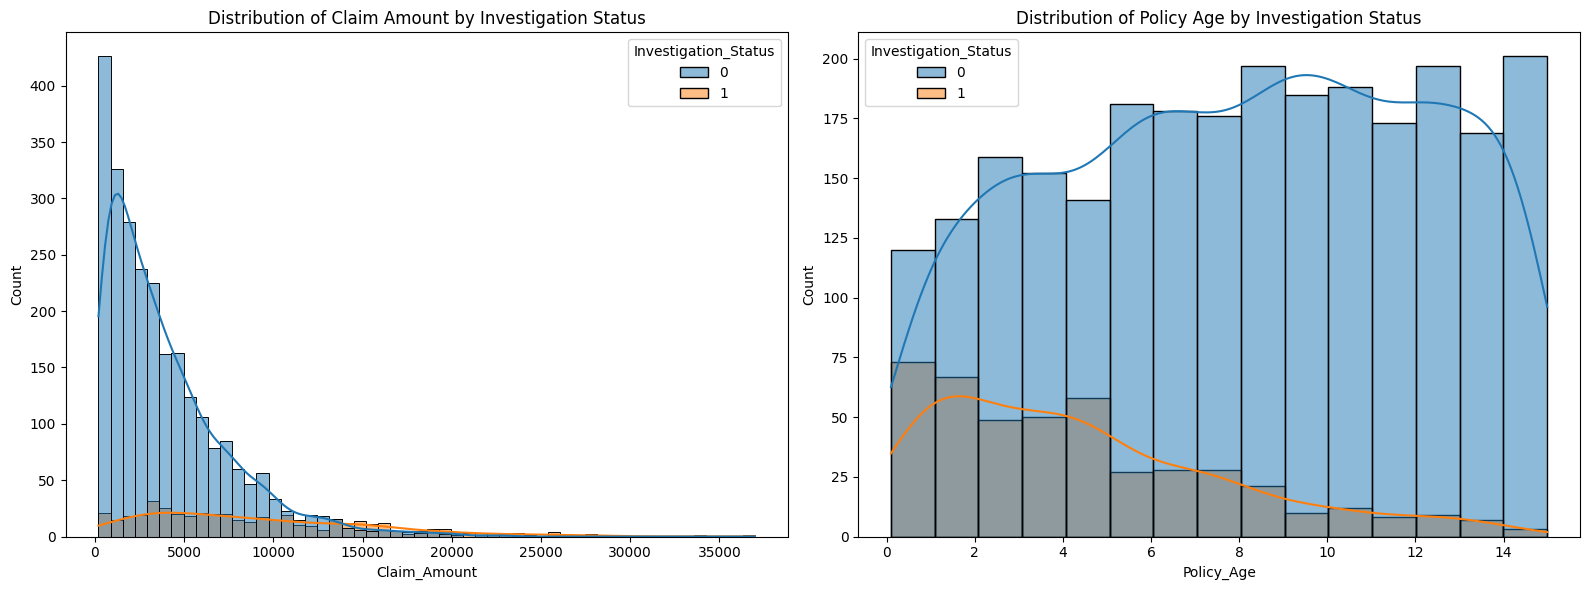

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='Claim_Amount', hue='Investigation_Status', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Claim Amount by Investigation Status')

sns.histplot(data=df, x='Policy_Age', hue='Investigation_Status', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Policy Age by Investigation Status')

plt.tight_layout()
plt.show()

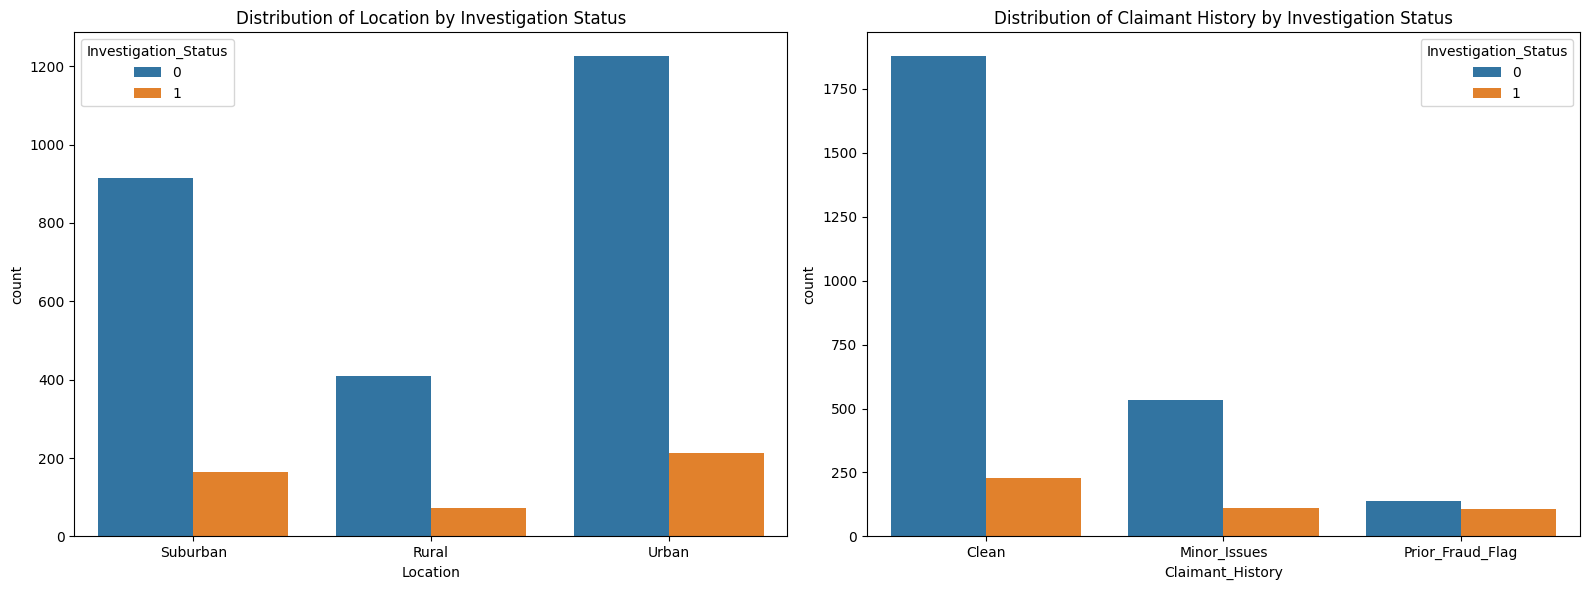

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='Location', hue='Investigation_Status', ax=axes[0])
axes[0].set_title('Distribution of Location by Investigation Status')

sns.countplot(data=df, x='Claimant_History', hue='Investigation_Status', ax=axes[1])
axes[1].set_title('Distribution of Claimant History by Investigation Status')

plt.tight_layout()
plt.show()

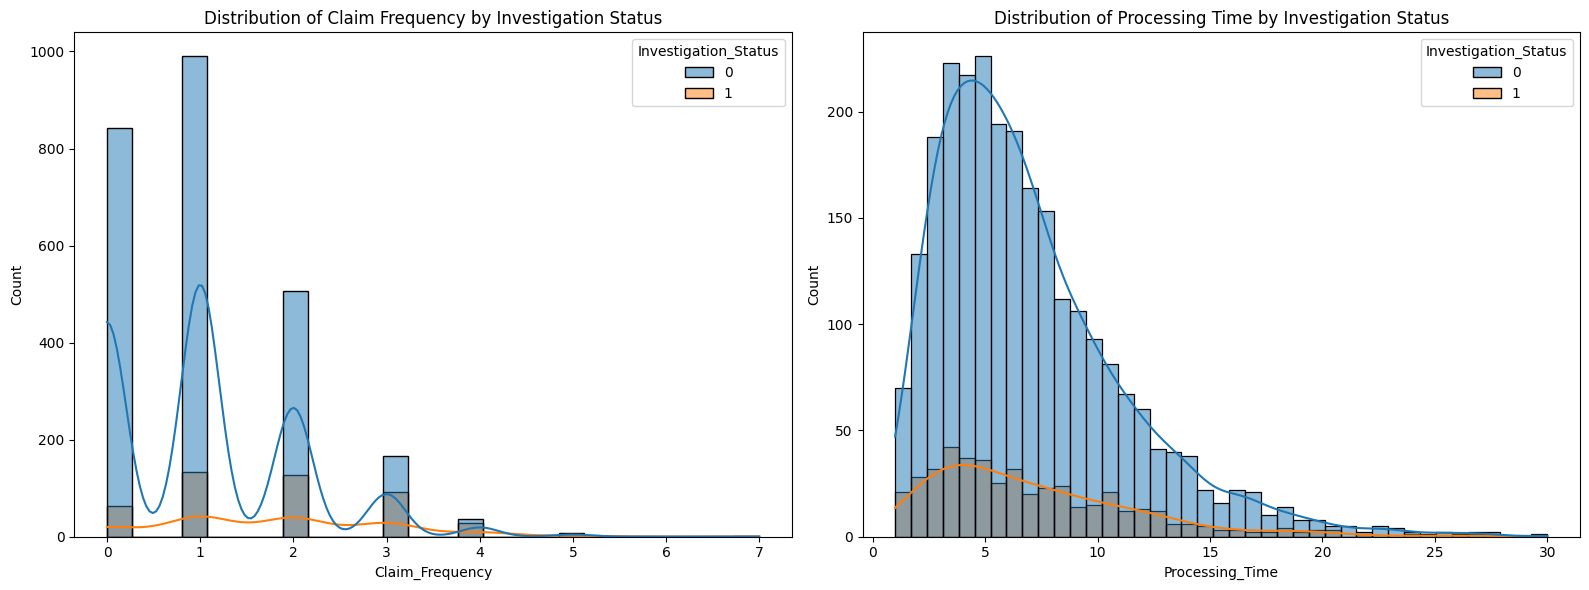

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='Claim_Frequency', hue='Investigation_Status', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Claim Frequency by Investigation Status')

sns.histplot(data=df, x='Processing_Time', hue='Investigation_Status', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Processing Time by Investigation Status')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop Claim_ID as it is not relevant for modeling
df_model = df.drop('Claim_ID', axis=1)

# Define target and features
X = df_model.drop('Investigation_Status', axis=1)
y = df_model['Investigation_Status']

# Identify categorical and numerical columns
categorical_features = ['Location', 'Claimant_History']
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding for better interpretability (optional)
# This step is a bit complex due to ColumnTransformer's output
# For simplicity, we'll proceed without explicit feature names for now,
# as the Random Forest model doesn't strictly require them for training.

# Split the data into training and testing sets
# Using stratify=y to maintain the class distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

print("Data preprocessing complete: Categorical features encoded, data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data preprocessing complete: Categorical features encoded, data split into training and testing sets.
X_train shape: (2100, 10), y_train shape: (2100,)
X_test shape: (900, 10), y_test shape: (900,)


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using class_weight='balanced' to handle the class imbalance observed earlier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Model Evaluation:
------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       765
           1       0.82      0.50      0.62       135

    accuracy                           0.91       900
   macro avg       0.87      0.74      0.79       900
weighted avg       0.90      0.91      0.90       900

Accuracy: 0.9089


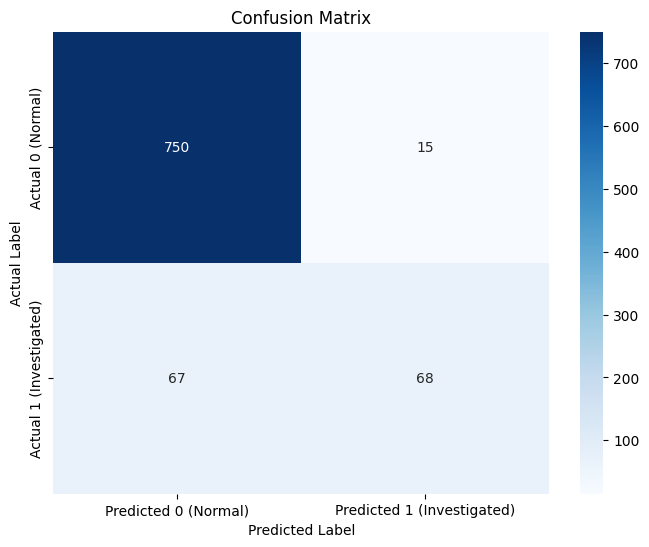

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1] # Probability of being an investigated claim

print("Model Evaluation:")
print("------------------")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (Normal)', 'Predicted 1 (Investigated)'],
            yticklabels=['Actual 0 (Normal)', 'Actual 1 (Investigated)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Key insights from confusion matrix:
# True Negatives (TN): cm[0,0] - Correctly predicted normal claims
# False Positives (FP): cm[0,1] - Incorrectly predicted normal claims as investigated
# False Negatives (FN): cm[1,0] - Incorrectly predicted investigated claims as normal
# True Positives (TP): cm[1,1] - Correctly predicted investigated claims

### Prioritizing Claims for Investigation

Now, let's create a list of claims that the model predicts as needing investigation, ordered by their probability of being suspicious. This will help the investigation team focus their efforts. We will also include the actual `Investigation_Status` to highlight where the model made correct or incorrect predictions.

In [13]:
# Get the original indices from the test set
test_indices = y_test.index

# Extract original Claim_IDs for the test set
original_claim_ids = df.loc[test_indices, 'Claim_ID']

# Create a DataFrame for investigation prioritization
investigation_list_df = pd.DataFrame({
    'Claim_ID': original_claim_ids,
    'Actual_Investigation_Status': y_test,
    'Predicted_Investigation_Status': y_pred,
    'Prediction_Probability': y_proba
})

# Filter for claims predicted as needing investigation (Predicted_Investigation_Status = 1)
prioritized_investigation_list = investigation_list_df[investigation_list_df['Predicted_Investigation_Status'] == 1]

# Sort by prediction probability in descending order to prioritize claims
prioritized_investigation_list = prioritized_investigation_list.sort_values(by='Prediction_Probability', ascending=False)

print("Prioritized List of Claims for Investigation (Predicted as 'Investigated'):")
display(prioritized_investigation_list.head(20)) # Display the top 20 prioritized claims

# Also show the false positives (predicted 1, actual 0) and false negatives (predicted 0, actual 1)
false_positives = prioritized_investigation_list[prioritized_investigation_list['Actual_Investigation_Status'] == 0]
false_negatives_mask = (investigation_list_df['Predicted_Investigation_Status'] == 0) & \
                       (investigation_list_df['Actual_Investigation_Status'] == 1)
false_negatives = investigation_list_df[false_negatives_mask]

print("\nFalse Positives (Claims predicted as 'Investigated' but were actually 'Normal'):")
display(false_positives.head())

print("\nFalse Negatives (Claims predicted as 'Normal' but were actually 'Investigated'):")
display(false_negatives.head())

Prioritized List of Claims for Investigation (Predicted as 'Investigated'):


,Claim_ID,Actual_Investigation_Status,Predicted_Investigation_Status,Prediction_Probability
2527,CLM-102527,1,1,0.91
2638,CLM-102638,1,1,0.89
498,CLM-100498,1,1,0.89
226,CLM-100226,1,1,0.89
1370,CLM-101370,1,1,0.88
785,CLM-100785,1,1,0.86
2451,CLM-102451,1,1,0.86
127,CLM-100127,1,1,0.85
1466,CLM-101466,1,1,0.84
2053,CLM-102053,1,1,0.84



False Positives (Claims predicted as 'Investigated' but were actually 'Normal'):


,Claim_ID,Actual_Investigation_Status,Predicted_Investigation_Status,Prediction_Probability
1564,CLM-101564,0,1,0.82
2107,CLM-102107,0,1,0.81
990,CLM-100990,0,1,0.74
1849,CLM-101849,0,1,0.72
235,CLM-100235,0,1,0.69



False Negatives (Claims predicted as 'Normal' but were actually 'Investigated'):


,Claim_ID,Actual_Investigation_Status,Predicted_Investigation_Status,Prediction_Probability
296,CLM-100296,1,0,0.01
2576,CLM-102576,1,0,0.36
1507,CLM-101507,1,0,0.44
477,CLM-100477,1,0,0.02
2806,CLM-102806,1,0,0.17


### Practical Action Plan and Next Steps

**1. Focus on the Prioritized List:**
   - The `Prioritized_Investigation_List` provides a ranked order of claims that the model believes are most likely to require investigation. The claims with higher `Prediction_Probability` should be reviewed first by human investigators.
   - Pay close attention to the `False Positives`. These are claims that the model flagged for investigation but were actually normal. While our model has a low number of false positives (15), reviewing them can help understand why the model made these incorrect high-confidence predictions and refine future models.

**2. Addressing False Negatives:**
   - The model currently has **67 False Negatives**, meaning it failed to identify 67 claims that actually needed investigation. This is a critical area for improvement.
   - **Strategy:** Review these false negatives. What characteristics do they share? Were there specific features that the model missed or undervalued? This analysis can guide feature engineering or model re-training.
   - **Potential Model Adjustments:** To reduce false negatives, we could:
     - **Adjust the classification threshold:** Currently, a default threshold of 0.5 is used. Lowering this threshold might increase the recall (capture more investigated claims) but could also increase false positives. A cost-benefit analysis would be needed.
     - **Explore different models:** Models like Gradient Boosting (XGBoost, LightGBM) or Support Vector Machines might offer different trade-offs in precision and recall.
     - **Feature Engineering:** Create new features that could better distinguish between normal and investigated claims (e.g., interaction terms, more complex historical data).
     - **Advanced Imputation/Outlier Handling:** Revisit how missing values were handled and consider more sophisticated outlier detection or treatment.

**3. Continuous Monitoring and Retraining:**
   - The model should be continuously monitored in a real-world setting. Its performance might degrade over time as claim patterns evolve.
   - Regularly retrain the model with new, labeled data to keep it accurate and relevant.

**4. Business Integration:**
   - Integrate the model's predictions into the existing claims processing workflow. The prioritized list can be a starting point for the investigation team.
   - Gather feedback from investigators on the model's predictions to further refine its performance and utility.

# Final Report: Analyzing Insurance Claims for Investigation Prioritization

## 1. Introduction and Objectives

The primary objective of this analysis was to develop a predictive model to identify insurance claims that require further investigation. By leveraging historical claims data, we aimed to:

*   **Clean and validate data:** Ensure data quality and handle missing values.
*   **Perform Exploratory Data Analysis (EDA):** Understand data distributions, relationships, and identify patterns.
*   **Identify distinguishing variables:** Compare suspicious (investigated) and normal claims to find key differences.
*   **Develop a classification model:** Build a Random Forest model to predict `Investigation_Status`.
*   **Evaluate model performance:** Assess the model's accuracy, precision, recall, and particularly its handling of false positives and false negatives.
*   **Prioritize investigation list:** Generate an actionable list of claims for human investigators.

## 2. Data Overview and Cleaning

The dataset `insurance_claims.xlsx` contained 3000 entries with several features including `Claim_ID`, `Claim_Amount`, `Policy_Age`, `Claim_Frequency`, `Location`, `Claimant_History`, `Processing_Time`, and `Investigation_Status` (our target variable).

**Data Cleaning Steps:**
*   Initial inspection revealed 30 missing values in both `Claim_Amount` and `Policy_Age`.
*   These missing values were imputed using the median of their respective columns.
*   No other missing values were found, ensuring a complete dataset for modeling.

## 3. Key Insights from Exploratory Data Analysis (EDA)

EDA provided crucial insights into variables that distinguish investigated claims from normal ones. The visualizations and descriptive statistics highlighted the following:

*   **`Claim_Amount`:** Investigated claims tend to have higher claim amounts compared to normal claims.
*   **`Policy_Age`:** Claims from newer policies (lower `Policy_Age`) showed a higher likelihood of investigation.
*   **`Location`:** 'Urban' locations appeared to have a proportionally higher number of investigated claims.
*   **`Claimant_History`:** Claims with a 'Prior_Fraud_Flag' or 'Minor_Issues' in the claimant's history were significantly more often investigated.
*   **`Claim_Frequency`:** Higher claim frequencies were associated with investigated claims.
*   **`Processing_Time`:** Investigated claims generally had longer processing times.

These variables are strong indicators for potential suspicious activity and were utilized by the model.

## 4. Classification Model Development and Evaluation

A **Random Forest Classifier** was chosen due to its robustness and ability to handle imbalanced datasets (using `class_weight='balanced'`).

**Preprocessing Steps:**
*   `Claim_ID` was dropped as it's not a predictive feature.
*   Categorical features (`Location`, `Claimant_History`) were one-hot encoded.
*   The dataset was split into training (70%) and testing (30%) sets, with stratification to preserve the class imbalance ratio.

**Model Performance (on Test Set):**
*   **Accuracy:** 90.89%
*   **Class 0 (Normal Claims):**
    *   Precision: 0.92
    *   Recall: 0.98
    *   F1-score: 0.95
*   **Class 1 (Investigated Claims):**
    *   Precision: 0.82
    *   Recall: 0.50
    *   F1-score: 0.62

**Confusion Matrix Breakdown:**
*   **True Positives (TP): 68** (Correctly identified investigated claims)
*   **True Negatives (TN): 750** (Correctly identified normal claims)
*   **False Positives (FP): 15** (Normal claims incorrectly flagged as investigated)
*   **False Negatives (FN): 67** (Investigated claims incorrectly flagged as normal)

**Key Evaluation Insights:**
*   The model is highly effective at identifying normal claims.
*   It has a low false positive rate (only 15 claims incorrectly flagged), which is excellent for minimizing wasted investigation effort.
*   However, the recall for investigated claims is moderate (0.50), meaning **67 potentially suspicious claims were missed (False Negatives)**. This is a critical area for improvement, as missing fraudulent claims can be costly.

## 5. Prioritized Investigation List

We generated a prioritized list of claims predicted by the model to require investigation, ordered by their probability of being suspicious. This list provides a direct output for investigators, allowing them to focus on the most high-risk cases first. The list also highlights false positives, which can be reviewed to understand model misclassifications.

## 6. Practical Action Plan and Next Steps

To maximize the utility of this model and improve its performance, especially in reducing false negatives, the following action plan is recommended:

1.  **Focus on the Prioritized List:** Utilize the generated list to guide investigations, starting with claims having the highest prediction probabilities. Reviewing false positives can help refine understanding of edge cases.

2.  **Address False Negatives:** This is the most critical area. Analyze the characteristics of the 67 false negative claims to identify common patterns or features the model may be overlooking. Consider:
    *   **Adjusting the classification threshold:** Lowering the threshold for classifying a claim as 'investigated' might increase recall but could also increase false positives. A cost-benefit analysis is needed.
    *   **Exploring different models:** Experiment with other advanced classification algorithms (e.g., Gradient Boosting) that might offer a better balance between precision and recall for Class 1.
    *   **Advanced Feature Engineering:** Develop new features or transform existing ones based on insights from the false negatives.

3.  **Continuous Monitoring and Retraining:** Implement a system for ongoing monitoring of the model's performance in a real-world environment. Regular retraining with new data is essential to adapt to evolving claim patterns.

4.  **Business Integration and Feedback:** Integrate the model's output directly into the claims processing workflow. Crucially, collect feedback from human investigators to iteratively improve the model and ensure its practical relevance and effectiveness.

### Cost-Benefit Analysis for Different Classification Thresholds

To optimize the model's performance for business needs, it's crucial to understand the trade-offs at different classification thresholds. We can define a simple cost function based on False Positives (FP) and False Negatives (FN). For this analysis, we will assume the following costs:

*   **Cost of a False Positive (FP):** $1 (representing the cost of an unnecessary investigation)
*   **Cost of a False Negative (FN):** $5 (representing the higher cost of a missed fraudulent claim, e.g., lost funds, reputational damage)

We will plot the total cost against different probability thresholds to find an optimal point where the total cost is minimized or an acceptable balance is achieved.

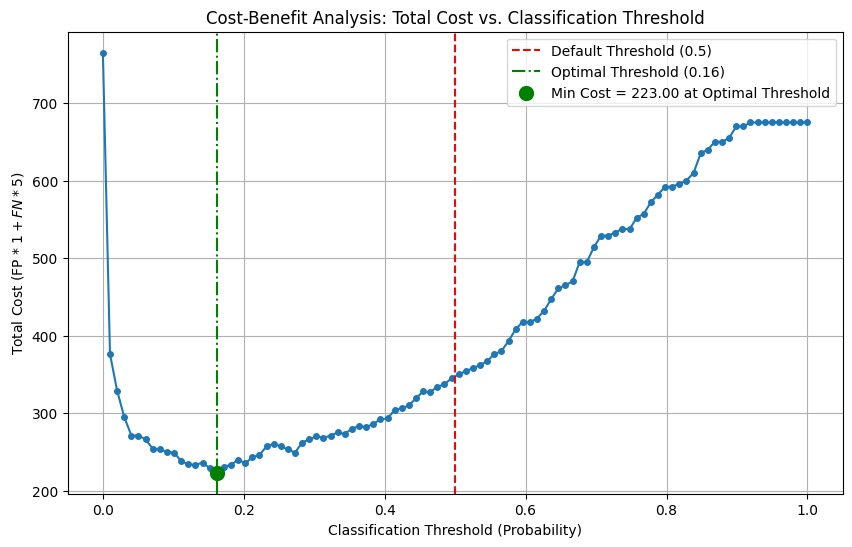

Optimal threshold to minimize total cost (FP*$1 + FN*$5): 0.16
Minimum total cost at this threshold: $223.00

Classification Report at Optimal Threshold (0.16):
              precision    recall  f1-score   support

           0       0.97      0.87      0.91       765
           1       0.52      0.82      0.64       135

    accuracy                           0.86       900
   macro avg       0.74      0.84      0.77       900
weighted avg       0.90      0.86      0.87       900



In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Define the cost of False Positives and False Negatives
COST_FP = 1  # Cost of investigating a normal claim
COST_FN = 5  # Cost of missing an investigated claim

# Generate a range of thresholds
thresholds = np.linspace(0, 1, 100)

total_costs = []

for threshold in thresholds:
    # Predict binary labels based on the current threshold
    y_pred_threshold = (y_proba >= threshold).astype(int)

    # Calculate confusion matrix for the current threshold
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    # Calculate total cost
    current_total_cost = (fp * COST_FP) + (fn * COST_FN)
    total_costs.append(current_total_cost)

# Plotting the Cost-Benefit Analysis
plt.figure(figsize=(10, 6))
plt.plot(thresholds, total_costs, marker='o', linestyle='-', markersize=4)
plt.title('Cost-Benefit Analysis: Total Cost vs. Classification Threshold')
plt.xlabel('Classification Threshold (Probability)')
plt.ylabel('Total Cost (FP * $1 + FN * $5)')
plt.grid(True)
plt.axvline(x=0.5, color='r', linestyle='--', label='Default Threshold (0.5)')

# Find the threshold that minimizes total cost
min_cost_index = np.argmin(total_costs)
optimal_threshold = thresholds[min_cost_index]
min_cost = total_costs[min_cost_index]

plt.axvline(x=optimal_threshold, color='g', linestyle='-.', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.scatter(optimal_threshold, min_cost, color='g', s=100, zorder=5, label=f'Min Cost = {min_cost:.2f} at Optimal Threshold')

plt.legend()
plt.show()

print(f"Optimal threshold to minimize total cost (FP*${COST_FP} + FN*${COST_FN}): {optimal_threshold:.2f}")
print(f"Minimum total cost at this threshold: ${min_cost:.2f}")

# Re-evaluate model performance at the optimal threshold for comparison
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print(f"\nClassification Report at Optimal Threshold ({optimal_threshold:.2f}):")
print(classification_report(y_test, y_pred_optimal))

### PowerBI-like Visualizations for Key Insights

To provide a comprehensive overview of the analysis, akin to a PowerBI dashboard, I will generate a series of visualizations focusing on:

1.  **Claim Status Distribution:** Overall proportion of normal vs. investigated claims.
2.  **Claim Amount & Policy Age:** Comparative distributions for investigated vs. normal claims.
3.  **Location & Claimant History:** Breakdown of investigation status across categorical features.
4.  **Model Performance Summary:** A visual representation of the confusion matrix and the impact of the optimal threshold.


/tmp/ipykernel_1551/1578026881.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Investigation_Status_Label', data=df, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_1551/1578026881.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend(title='Status')
/tmp/ipykernel_1551/1578026881.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend(title='Status')
/tmp/ipykernel_1551/1578026881.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` f

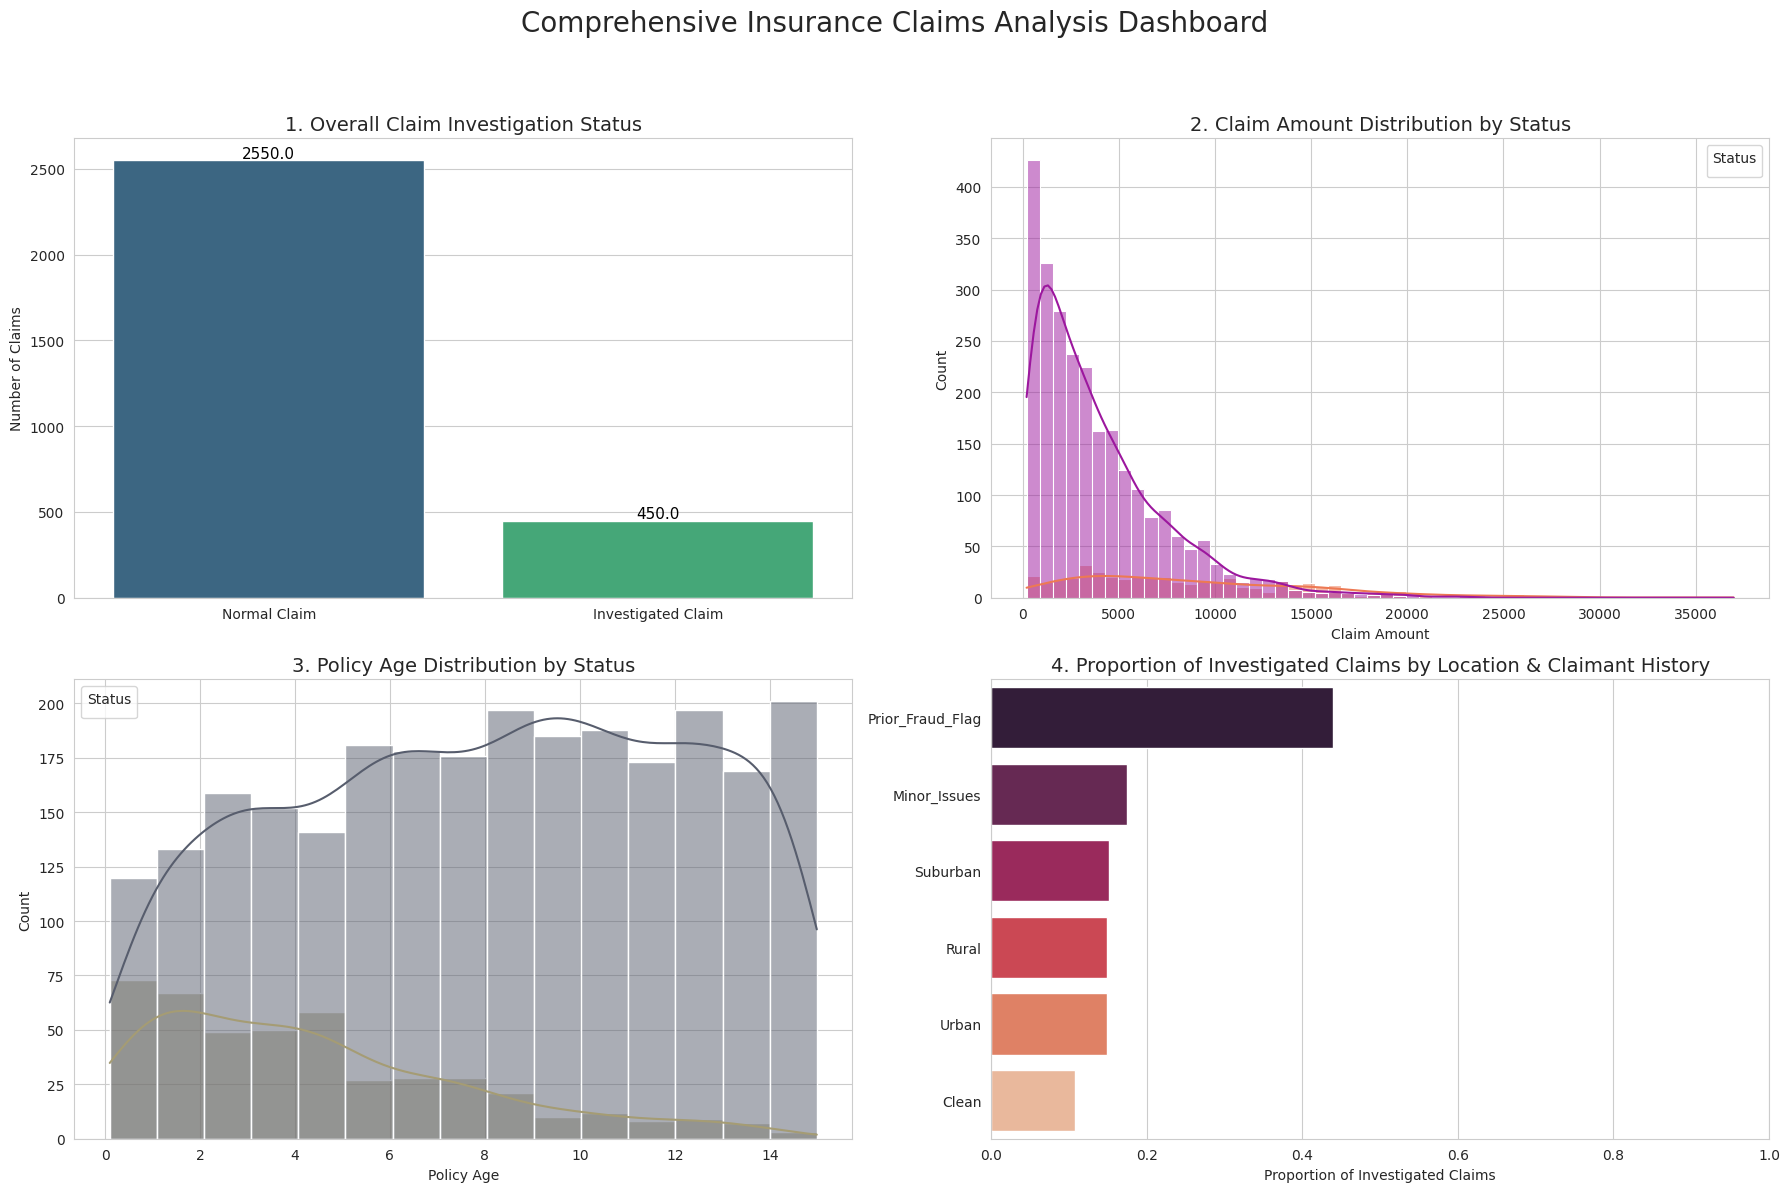

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the plots
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Set higher DPI for better resolution

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comprehensive Insurance Claims Analysis Dashboard', fontsize=20, y=1.02)

# Plot 1: Overall Investigation Status Distribution
df['Investigation_Status_Label'] = df['Investigation_Status'].map({0: 'Normal Claim', 1: 'Investigated Claim'})
sns.countplot(x='Investigation_Status_Label', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('1. Overall Claim Investigation Status', fontsize=14)
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Number of Claims')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# Plot 2: Claim Amount Distribution by Investigation Status
sns.histplot(data=df, x='Claim_Amount', hue='Investigation_Status_Label', kde=True, ax=axes[0, 1], palette='plasma', common_norm=False)
axes[0, 1].set_title('2. Claim Amount Distribution by Status', fontsize=14)
axes[0, 1].set_xlabel('Claim Amount')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Status')

# Plot 3: Policy Age Distribution by Investigation Status
sns.histplot(data=df, x='Policy_Age', hue='Investigation_Status_Label', kde=True, ax=axes[1, 0], palette='cividis', common_norm=False)
axes[1, 0].set_title('3. Policy Age Distribution by Status', fontsize=14)
axes[1, 0].set_xlabel('Policy Age')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(title='Status')

# Plot 4: Location and Claimant History - Proportion of Investigated Claims
# Calculate proportions for Location
location_proportions = df.groupby('Location')['Investigation_Status'].value_counts(normalize=True).unstack().fillna(0)
location_proportions['Investigated_Proportion'] = location_proportions[1] # Proportion of '1'
location_proportions = location_proportions.sort_values(by='Investigated_Proportion', ascending=False)

# Calculate proportions for Claimant_History
claimant_history_proportions = df.groupby('Claimant_History')['Investigation_Status'].value_counts(normalize=True).unstack().fillna(0)
claimant_history_proportions['Investigated_Proportion'] = claimant_history_proportions[1]
claimant_history_proportions = claimant_history_proportions.sort_values(by='Investigated_Proportion', ascending=False)

# Create a combined bar plot for Location and Claimant History
combined_proportions = pd.concat([
    location_proportions['Investigated_Proportion'].rename('Location'),
    claimant_history_proportions['Investigated_Proportion'].rename('Claimant History')
]).reset_index()
combined_proportions.columns = ['Category_Type', 'Investigated_Proportion']

sns.barplot(x='Investigated_Proportion', y='Category_Type', data=combined_proportions.sort_values(by='Investigated_Proportion', ascending=False),
            ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('4. Proportion of Investigated Claims by Location & Claimant History', fontsize=14)
axes[1, 1].set_xlabel('Proportion of Investigated Claims')
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlim(0, 1)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

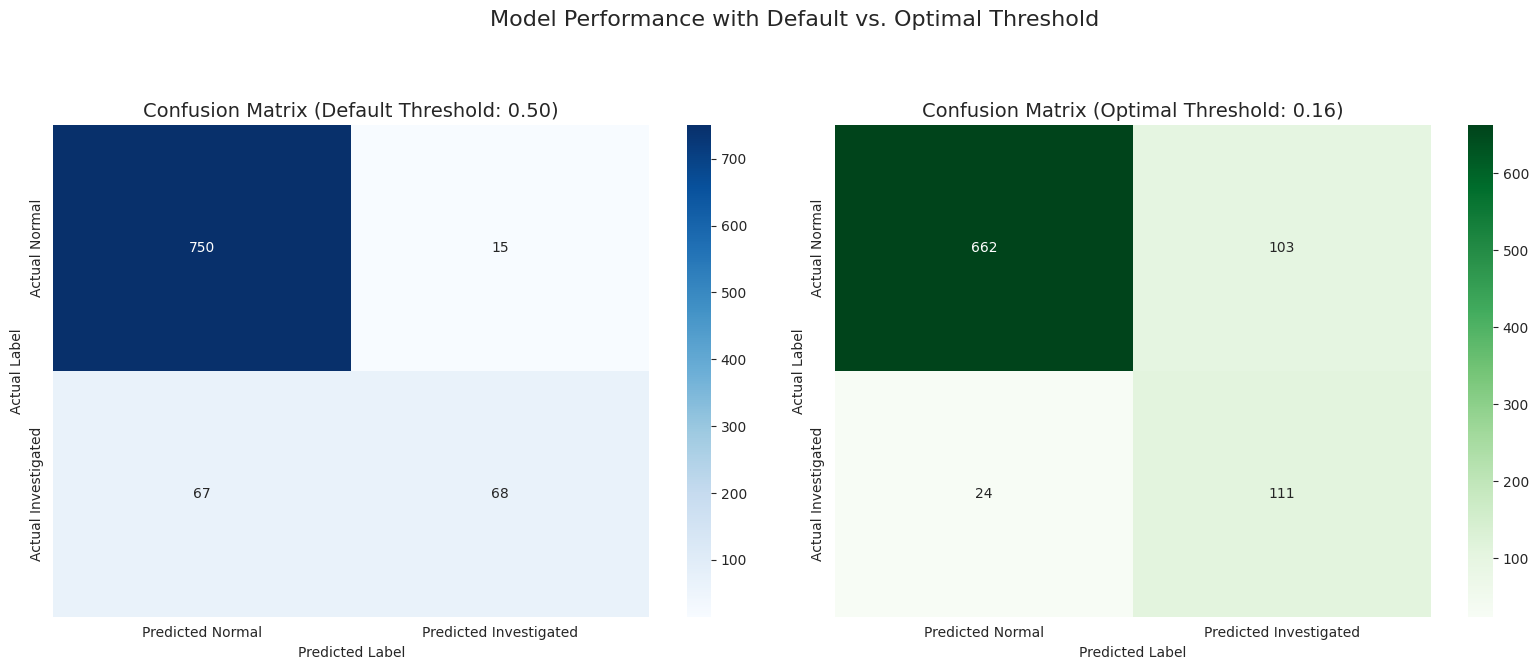

In [16]:
from sklearn.metrics import confusion_matrix

# Re-calculate confusion matrix for the optimal threshold (0.16)
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

# Create a figure with two subplots for confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Model Performance with Default vs. Optimal Threshold', fontsize=16)

# Plot Confusion Matrix for Default Threshold (0.5)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Investigated'],
            yticklabels=['Actual Normal', 'Actual Investigated'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Default Threshold: 0.50)', fontsize=14)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Plot Confusion Matrix for Optimal Threshold (0.16)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Normal', 'Predicted Investigated'],
            yticklabels=['Actual Normal', 'Actual Investigated'], ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Optimal Threshold: {optimal_threshold:.2f})', fontsize=14)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.92]) # Adjust layout to prevent suptitle overlap
plt.show()